# Análisis de Absentismo Laboral - RRHH (13-JUL-2026)

---

### Preguntas de negocio

> Cómo influyen  en los niveles de absentismo los factores de:
- el consumo social de alcohol
- el consumo social de tabaco 
- los antecedentes disciplinarios

 > Cómo podríamos diseñar acciones preventivas y culturales para promover un entorno laboral más saludable y minimizar el impacto del absentismo?
 ---


### Antecedente:

En la semana anterior se desarrolló un modelo de regresión logística binaria, en el que la variable dependiente clasificaba a los empleados según pertenecieran o no al grupo de alto absentismo.
Resultados: sólo `Disciplinary Failure` salió estadísticamente significativa y con una alta probabilidad (aprox. 10%) de que, controlando el resto de variables, un miembro que sí tenga una falta disciplinaria forme parte del grupo de **absentismo alto**. Los resultados de las otras 2 variables de interés de esta semana fueron que el consumo social de alcohol y tabaco no mostraron una asociación estadísticamente significativa tras ajustar por el resto de variables:

- consumo social de **alcohol**: OR = 1,84 pero p-valor = 0,442*
- consumo social de **tabaco**: OR = 1,94 pero p-valor = 0,328*

*No se podía asegurar que los resultados no se debieran al azar en los registros de los empleados analizados.

---

### Pasos

1. La variable dependiente deja de ser binaria y pasa a representarse mediante tres categorías ordinales (bajo, medio y alto absentismo).
2. Ajustar un modelo de regresión logística ordinal dado que la variable dependiente del análisis multivariante deja de ser binario (si el empleado forma parte de la categoría alto_absentismo o no).
3. Evaluar el efectos de las 3 variables sobre la probabilidad de pertenecer a uno los grupos de absentismo medida mediante odds ratios e intervalos de confianza.

### Justificación metodológica

Variables involucradas:
- Total 

### Metodología:

1. **Agregación por empleado.** Los registros del dataset son solicitudes de ausencia, no empleados individuales. Se agregan a nivel de persona (x empleados), para garantizar la independencia de las observaciones.


## 1. Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date, time, timedelta
from getpass import getpass
from sqlalchemy import create_engine, inspect
from sqlalchemy.exc import SQLAlchemyError
import statsmodels.formula.api as smf
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np

import os
from dotenv import load_dotenv

## 2. Carga de datos <span style="color: red;">(CAMBIAR NAME CSV  Y TABLA mysql)</span>

In [4]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv(dotenv_path=".env")
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN_07072026;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente desde MySQL.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-07-06.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados correctamente desde el archivo CSV.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos cargados correctamente desde el archivo CSV.'

## 3. Preparación del dataset

### 3.1 Agregación por empleado

- Las horas de absentismo se agregan mediante **suma** (el total acumulado del período). 
- Se dividen en tres niveles usando el **percetil 33** 

In [15]:
# ============================================================
# 1. Una fila por empleado: sumar todas sus horas
# ============================================================

df_empleados = (
    df.groupby("ID_Employee", as_index=False)
    .agg(
        Total_Horas_Absentismo=("Absenteeism_Hours", "sum"),
        Social_Drinker=("Social_Drinker", "first"),
        Social_Smoker=("Social_Smoker", "first"),
        Disciplinary_Failure=("Disciplinary_Failure", "max")
    )
)

print("Empleados únicos:", df["ID_Employee"].nunique())
print("Filas de la tabla agrupada:", len(df_empleados))

# Ver el total de horas de cada empleado
df_empleados[
    ["ID_Employee", "Total_Horas_Absentismo"]
].sort_values(
    "Total_Horas_Absentismo",
    ascending=False
)

Empleados únicos: 136
Filas de la tabla agrupada: 136


,ID_Employee,Total_Horas_Absentismo
13,14,476
10,11,450
2,3,444
27,28,343
33,34,333
...,...,...
38,39,0
34,35,0
87,88,0
74,75,0


In [16]:
# ============================================================
# 2. Calcular percentiles sobre las horas totales por empleado
# ============================================================

p33 = df_empleados["Total_Horas_Absentismo"].quantile(0.33)
p66 = df_empleados["Total_Horas_Absentismo"].quantile(0.66)

print(f"Percentil 33: {p33:.2f} horas acumuladas")
print(f"Percentil 66: {p66:.2f} horas acumuladas")

# ============================================================
# 3. Crear los tres grupos
# ============================================================

df_empleados["Nivel_Absentismo"] = np.select(
    [
        df_empleados["Total_Horas_Absentismo"] <= p33,
        df_empleados["Total_Horas_Absentismo"] <= p66
    ],
    [
        0,  # Bajo
        1   # Medio
    ],
    default=2  # Alto
).astype(int)

df_empleados["Nivel_Absentismo_Desc"] = (
    df_empleados["Nivel_Absentismo"].map({
        0: "Bajo",
        1: "Medio",
        2: "Alto"
    })
)

Percentil 33: 3.00 horas acumuladas
Percentil 66: 8.00 horas acumuladas


In [13]:
resumen_grupos = (
    df_empleados
    .groupby("Nivel_Absentismo_Desc")
    .agg(
        Empleados=("ID_Employee", "count"),
        Horas_Minimas=("Total_Horas_Absentismo", "min"),
        Horas_Maximas=("Total_Horas_Absentismo", "max"),
        Media_Horas=("Total_Horas_Absentismo", "mean"),
        Mediana_Horas=("Total_Horas_Absentismo", "median"),
        Total_Horas_Grupo=("Total_Horas_Absentismo", "sum")
    )
    .reindex(["Bajo", "Medio", "Alto"])
    .reset_index()
)

resumen_grupos.round(2)

,Nivel_Absentismo_Desc,Empleados,Horas_Minimas,Horas_Maximas,Media_Horas,Mediana_Horas,Total_Horas_Grupo
0,Bajo,51,0,3,1.73,2.0,88
1,Medio,44,4,8,7.09,8.0,312
2,Alto,41,16,476,131.63,73.0,5397


In [17]:
# ============================================================
# 1. Preparar datos para el modelo
# ============================================================

variables_modelo = [
    "Social_Drinker",
    "Social_Smoker",
    "Disciplinary_Failure"
]

df_modelo_ordinal = df_empleados[
    [
        "ID_Employee",
        "Nivel_Absentismo",
        "Nivel_Absentismo_Desc",
        *variables_modelo
    ]
].dropna().copy()

df_modelo_ordinal["Nivel_Absentismo"] = (
    df_modelo_ordinal["Nivel_Absentismo"].astype(int)
)

df_modelo_ordinal[variables_modelo] = (
    df_modelo_ordinal[variables_modelo].astype(int)
)

# Comprobar distribución
print("Distribución de los niveles:")
print(
    df_modelo_ordinal["Nivel_Absentismo_Desc"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto"])
)

print("\nDistribución de las variables:")
for variable in variables_modelo:
    print(f"\n{variable}")
    print(df_modelo_ordinal[variable].value_counts().sort_index())

# ============================================================
# 2. Regresión logística ordinal
# ============================================================

X = df_modelo_ordinal[variables_modelo].astype(float)
y = df_modelo_ordinal["Nivel_Absentismo"]

# OrderedModel no debe incluir una constante
modelo_ordinal_3 = OrderedModel(
    endog=y,
    exog=X,
    distr="logit"
)

resultado_ordinal_3 = modelo_ordinal_3.fit(
    method="bfgs",
    maxiter=1000,
    disp=False
)

print(resultado_ordinal_3.summary())

Distribución de los niveles:
Nivel_Absentismo_Desc
Bajo     51
Medio    44
Alto     41
Name: count, dtype: int64

Distribución de las variables:

Social_Drinker
Social_Drinker
0    59
1    77
Name: count, dtype: int64

Social_Smoker
Social_Smoker
0    121
1     15
Name: count, dtype: int64

Disciplinary_Failure
Disciplinary_Failure
0    109
1     27
Name: count, dtype: int64
                             OrderedModel Results                             
Dep. Variable:       Nivel_Absentismo   Log-Likelihood:                -142.69
Model:                   OrderedModel   AIC:                             295.4
Method:            Maximum Likelihood   BIC:                             310.0
Date:               ma., 14 jul. 2026                                         
Time:                        12:44:39                                         
No. Observations:                 136                                         
Df Residuals:                     131                                

In [18]:
# ============================================================
# 3. Resultados interpretables
# ============================================================

coeficientes = resultado_ordinal_3.params[variables_modelo]
p_values = resultado_ordinal_3.pvalues[variables_modelo]
intervalos = resultado_ordinal_3.conf_int().loc[variables_modelo]

resultados_modelo_3 = pd.DataFrame({
    "Variable": variables_modelo,
    "Coeficiente": coeficientes,
    "Odds_Ratio": np.exp(coeficientes),
    "IC_95_Inferior": np.exp(intervalos[0]),
    "IC_95_Superior": np.exp(intervalos[1]),
    "P_Value": p_values
}).reset_index(drop=True)

resultados_modelo_3["Significativa"] = np.where(
    resultados_modelo_3["P_Value"] < 0.05,
    "Sí",
    "No"
)

resultados_modelo_3 = resultados_modelo_3.sort_values(
    "P_Value"
).reset_index(drop=True)

resultados_modelo_3.round(4)

,Variable,Coeficiente,Odds_Ratio,IC_95_Inferior,IC_95_Superior,P_Value,Significativa
0,Disciplinary_Failure,1.4595,4.3040,1.7213,10.7621,0.0018,Sí
1,Social_Smoker,0.4694,1.5991,0.5524,4.6291,0.3867,No
2,Social_Drinker,-0.1280,0.8799,0.4626,1.6734,0.6964,No


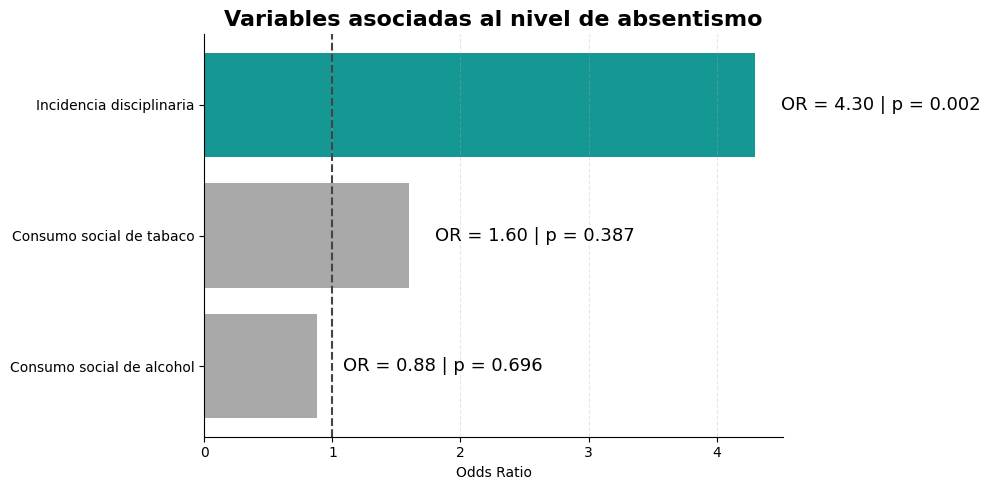

In [30]:


grafico = resultados_modelo_3.copy()

nombres = {
    "Social_Drinker": "Consumo social de alcohol",
    "Social_Smoker": "Consumo social de tabaco",
    "Disciplinary_Failure": "Incidencia disciplinaria"
}

grafico["Variable_Desc"] = grafico["Variable"].map(nombres)
grafico = grafico.sort_values("Odds_Ratio")

colores = [
    "#159793" if p < 0.05 else "#A9A9A9"
    for p in grafico["P_Value"]
]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    grafico["Variable_Desc"],
    grafico["Odds_Ratio"],
    color=colores
)

# Línea OR = 1
ax.axvline(
    1,
    color="#444444",
    linestyle="--",
    linewidth=1.5
)

# Etiquetas
for bar, or_value, p_value in zip(
    bars,
    grafico["Odds_Ratio"],
    grafico["P_Value"]
):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"OR = {or_value:.2f} | p = {p_value:.3f}",
        va="center",
        fontsize=13
    )

ax.set_title(
    "Variables asociadas al nivel de absentismo",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Odds Ratio")

ax.grid(axis="x", linestyle="--", alpha=0.3)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()